# Mask-aligned one-demo overfit: failed-grasp analysis

This notebook analyzes `outputs/libero_object_task0_demo0_overfit_mask_aligned/artifact`. It separates three questions:

1. Does RDT reproduce commands on cached demonstrated observations?
2. During a real chunk-4 rollout, when do commands and physical states first depart from demo 0?
3. At the demonstrated grasp transition, is failure caused by motion, gripper timing, or both?

The live-rollout cell is the only expensive cell. It writes an action trace, synchronized state/camera trace, and MP4 so later cells are inexpensive and reproducible.

## 1. Paths and imports

In [31]:
from pathlib import Path
import json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Video, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src/thinkflow_rdt').exists():
    REPO_ROOT = REPO_ROOT.parent
for path in (REPO_ROOT / 'src', REPO_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from thinkflow_rdt.adapters.libero import (
    iter_libero_episodes, ortho6d_to_rotation_matrix, rdt_action_to_libero,
)

RUN_ROOT = REPO_ROOT / 'outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500'
ARTIFACT = RUN_ROOT / 'artifact'
REPORT_PATH = RUN_ROOT / 'report.json'
SNAPSHOT_PATH = RUN_ROOT / 'sampled_predictions.pt'
CACHE_ROOT = REPO_ROOT / 'cache_features_libero_object_task0_demo0'
BASE_ARTIFACT = REPO_ROOT / 'oxe_b0_merged_for_libero'
DEMO_HDF5 = REPO_ROOT / 'libero-dataset/libero_object/pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5'
DEMO_NAME = 'demo_0'
for path in (ARTIFACT, REPORT_PATH, SNAPSHOT_PATH, CACHE_ROOT, BASE_ARTIFACT, DEMO_HDF5):
    assert path.exists(), path
print('Repository:', REPO_ROOT)
print('Checkpoint:', ARTIFACT)

Repository: /home/ubuntu/ThinkFlow-RDT-1B
Checkpoint: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/artifact


## 2. Training report and real-sampling progression

The report distinguishes denoising loss from actual five-call diffusion sampling. The latter is the more relevant offline diagnostic.

In [32]:
report = json.loads(REPORT_PATH.read_text())
sampling_history = [row for row in report['history'] if 'real_sampling' in row]
training_history = [row for row in report['history'] if 'total_loss' in row]
final_sampling = sampling_history[-1]['real_sampling']
final_training = training_history[-1]
display({
    'training_samples': report['configuration']['training_sample_count'],
    'optimizer_steps': report['configuration']['steps'],
    'approximate_epochs': report['configuration']['approximate_sample_epochs'],
    'inference_steps': report['configuration']['inference_steps'],
    'rollout': report['rollout'],
})
display(pd.DataFrame([final_training]).set_index('step'))
display(pd.DataFrame([
    {'horizon': int(h), **values}
    for h, values in final_sampling['horizon_rmse'].items()
]).set_index('horizon'))
display(pd.DataFrame(final_sampling['gripper_phase']).T)

{'training_samples': 148,
 'optimizer_steps': 1000,
 'approximate_epochs': 864.8648648648649,
 'inference_steps': 5,
 'rollout': {'episodes': 1,
  'successes': 0,
  'success_rate': 0.0,
  'tasks': [{'task_id': 0,
    'instruction': 'pick up the alphabet soup and place it in the basket',
    'episodes': 1,
    'successes': 0,
    'success_rate': 0.0}],
  'requested_episodes': 1,
  'complete': True,
  'output_dir': '/home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/rollout_20260810_133253'}}

,total_loss,weighted_imitation_loss,gripper_bce_loss,rotation_geodesic_loss,unweighted_denoising_loss,grad_norm
step,,,,,,
1000,0.019392,0.004963,0.014359,0.000089,0.004639,0.628112


,command_rmse_7d,motion_rmse_6d,gripper_rmse,valid_commands
horizon,,,,
1,0.106987,0.078495,0.207737,64
4,0.085142,0.064041,0.161668,253
8,0.092065,0.063461,0.187531,499
64,0.108166,0.073651,0.222154,3223


,accuracy,commands,opportunities,detected,missed,mean_signed_error_steps,mae_steps
approach_open,0.995062,405.0,NaN,NaN,NaN,NaN,NaN
close_hold,0.992508,2269.0,NaN,NaN,NaN,NaN,NaN
release_open,0.934426,549.0,NaN,NaN,NaN,NaN,NaN
release_transition_timing,NaN,NaN,27.0,27.0,0.0,1.148148,1.518519


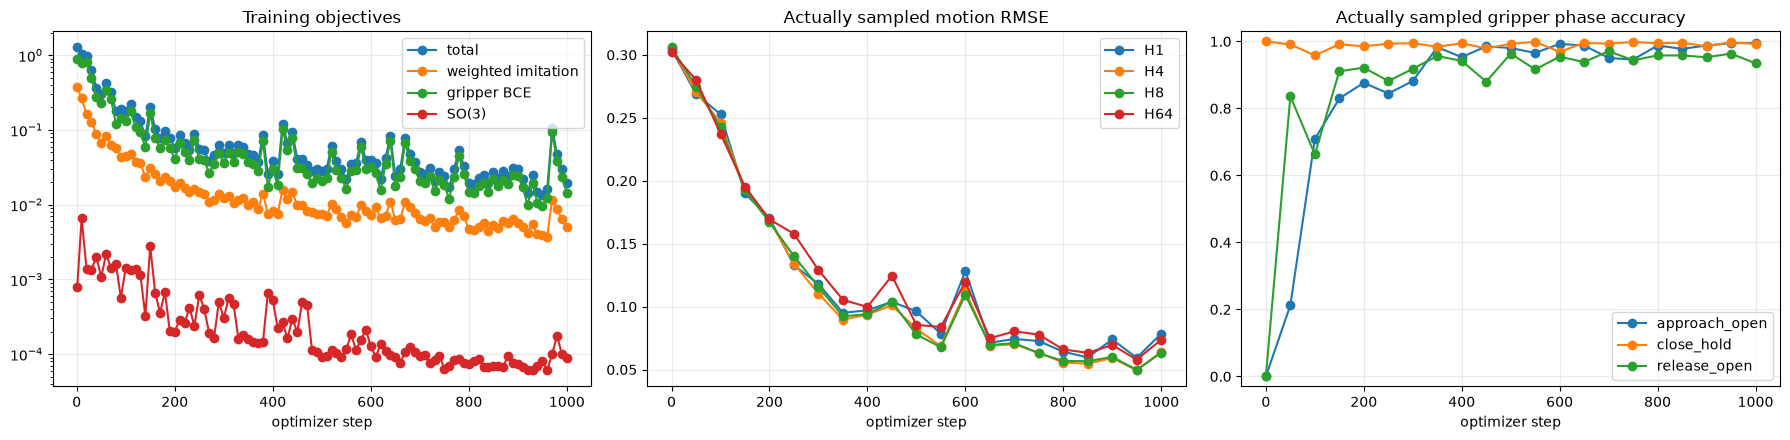

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
train_steps = [row['step'] for row in training_history]
for key, label in (
    ('total_loss', 'total'), ('weighted_imitation_loss', 'weighted imitation'),
    ('gripper_bce_loss', 'gripper BCE'), ('rotation_geodesic_loss', 'SO(3)'),
):
    axes[0].plot(train_steps, [row[key] for row in training_history], marker='o', label=label)
axes[0].set_yscale('log'); axes[0].set_title('Training objectives'); axes[0].legend()

sample_steps = [row['step'] for row in sampling_history]
for horizon, color in zip(('1', '4', '8', '64'), ('tab:blue', 'tab:orange', 'tab:green', 'tab:red')):
    axes[1].plot(sample_steps, [row['real_sampling']['horizon_rmse'][horizon]['motion_rmse_6d'] for row in sampling_history], marker='o', color=color, label=f'H{horizon}')
axes[1].set_title('Actually sampled motion RMSE'); axes[1].legend()

for phase, color in (('approach_open', 'tab:blue'), ('close_hold', 'tab:orange'), ('release_open', 'tab:green')):
    axes[2].plot(sample_steps, [row['real_sampling']['gripper_phase'][phase]['accuracy'] for row in sampling_history], marker='o', color=color, label=phase)
axes[2].set_ylim(-.03, 1.03); axes[2].set_title('Actually sampled gripper phase accuracy'); axes[2].legend()
for ax in axes:
    ax.set_xlabel('optimizer step'); ax.grid(alpha=.25)
plt.tight_layout()

## 3. Final teacher-forced samples

These predictions use cached images, state, T5, Qwen KV, and SigLIP features from demonstrated observations. They test memorization before closed-loop drift is introduced.

In [34]:
snapshot_store = torch.load(SNAPSHOT_PATH, map_location='cpu', weights_only=False)
snapshot_key = max(snapshot_store, key=lambda key: int(key.rsplit('_', 1)[1]))
snapshot = snapshot_store[snapshot_key]
prediction_10d = snapshot['prediction_10d'].float().numpy()
target_10d = snapshot['target_10d'].float().numpy()
time_mask = snapshot['time_mask'].bool().numpy()
prediction_7d = rdt_action_to_libero(prediction_10d)
target_7d = rdt_action_to_libero(target_10d)
audit_steps = np.asarray(report['configuration']['real_sampling_audit_indices'], dtype=int)
assert len(audit_steps) == len(prediction_10d)
episode = next(ep for ep in iter_libero_episodes(DEMO_HDF5) if ep.episode_id.endswith(DEMO_NAME))
# LiberoEpisode stores the cache/model 10D ortho6D command. Decode it
# back to the raw 7D LIBERO controller command before comparing signs.
demo_actions_10d = np.asarray(episode.actions, dtype=np.float32)
demo_actions = rdt_action_to_libero(demo_actions_10d)
demo_states = np.asarray(episode.states, dtype=np.float32)
demo_gripper_closed = demo_actions[:, 6] >= 0
transitions = np.flatnonzero(demo_gripper_closed[1:] != demo_gripper_closed[:-1]) + 1
grasp_candidates = transitions[demo_gripper_closed[transitions]]
release_candidates = transitions[~demo_gripper_closed[transitions]]
GRASP_STEP = int(grasp_candidates[0]) if len(grasp_candidates) else None
RELEASE_STEP = int(release_candidates[-1]) if len(release_candidates) else None
display({
    'snapshot': snapshot_key, 'audit_conditions': len(audit_steps),
    'demo_length': len(demo_actions), 'raw_gripper_sign_transitions': transitions.tolist(),
    'grasp_close_step': GRASP_STEP, 'release_open_step': RELEASE_STEP,
})

{'snapshot': 'step_001000',
 'audit_conditions': 64,
 'demo_length': 148,
 'raw_gripper_sign_transitions': [42, 128],
 'grasp_close_step': 42,
 'release_open_step': 128}

In [35]:
command_names = ['dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'gripper']
rows = []
for horizon in (1, 4, 8, 64):
    valid = time_mask[:, :horizon]
    pred = prediction_7d[:, :horizon][valid]
    true = target_7d[:, :horizon][valid]
    rows.append({
        'horizon': horizon,
        'motion_RMSE': float(np.sqrt(np.mean((pred[:, :6] - true[:, :6]) ** 2))),
        'gripper_sign_accuracy': float(np.mean((pred[:, 6] >= 0) == (true[:, 6] >= 0))),
        'commands': len(pred),
    })
display(pd.DataFrame(rows).set_index('horizon'))

valid4 = time_mask[:, :4]
pred4 = prediction_7d[:, :4][valid4]
true4 = target_7d[:, :4][valid4]
dimension_rows = []
for index, name in enumerate(command_names):
    correlation = np.corrcoef(pred4[:, index], true4[:, index])[0, 1] if np.std(pred4[:, index]) > 0 and np.std(true4[:, index]) > 0 else np.nan
    dimension_rows.append({
        'dimension': name,
        'RMSE': float(np.sqrt(np.mean((pred4[:, index] - true4[:, index]) ** 2))),
        'correlation': float(correlation),
        'sign_agreement': float(np.mean((pred4[:, index] >= 0) == (true4[:, index] >= 0))),
    })
display(pd.DataFrame(dimension_rows).set_index('dimension'))

,motion_RMSE,gripper_sign_accuracy,commands
horizon,,,
1,0.078495,0.984375,64
4,0.064041,0.988142,253
8,0.063461,0.985972,499
64,0.073651,0.982935,3223


,RMSE,correlation,sign_agreement
dimension,,,
dx,0.066755,0.954471,0.909091
dy,0.079785,0.987103,0.798419
dz,0.114984,0.979247,0.762846
dRx,0.012191,0.886963,0.565217
dRy,0.018974,0.959231,0.960474
dRz,0.007461,0.936233,0.664032
gripper,0.161668,0.986499,0.988142


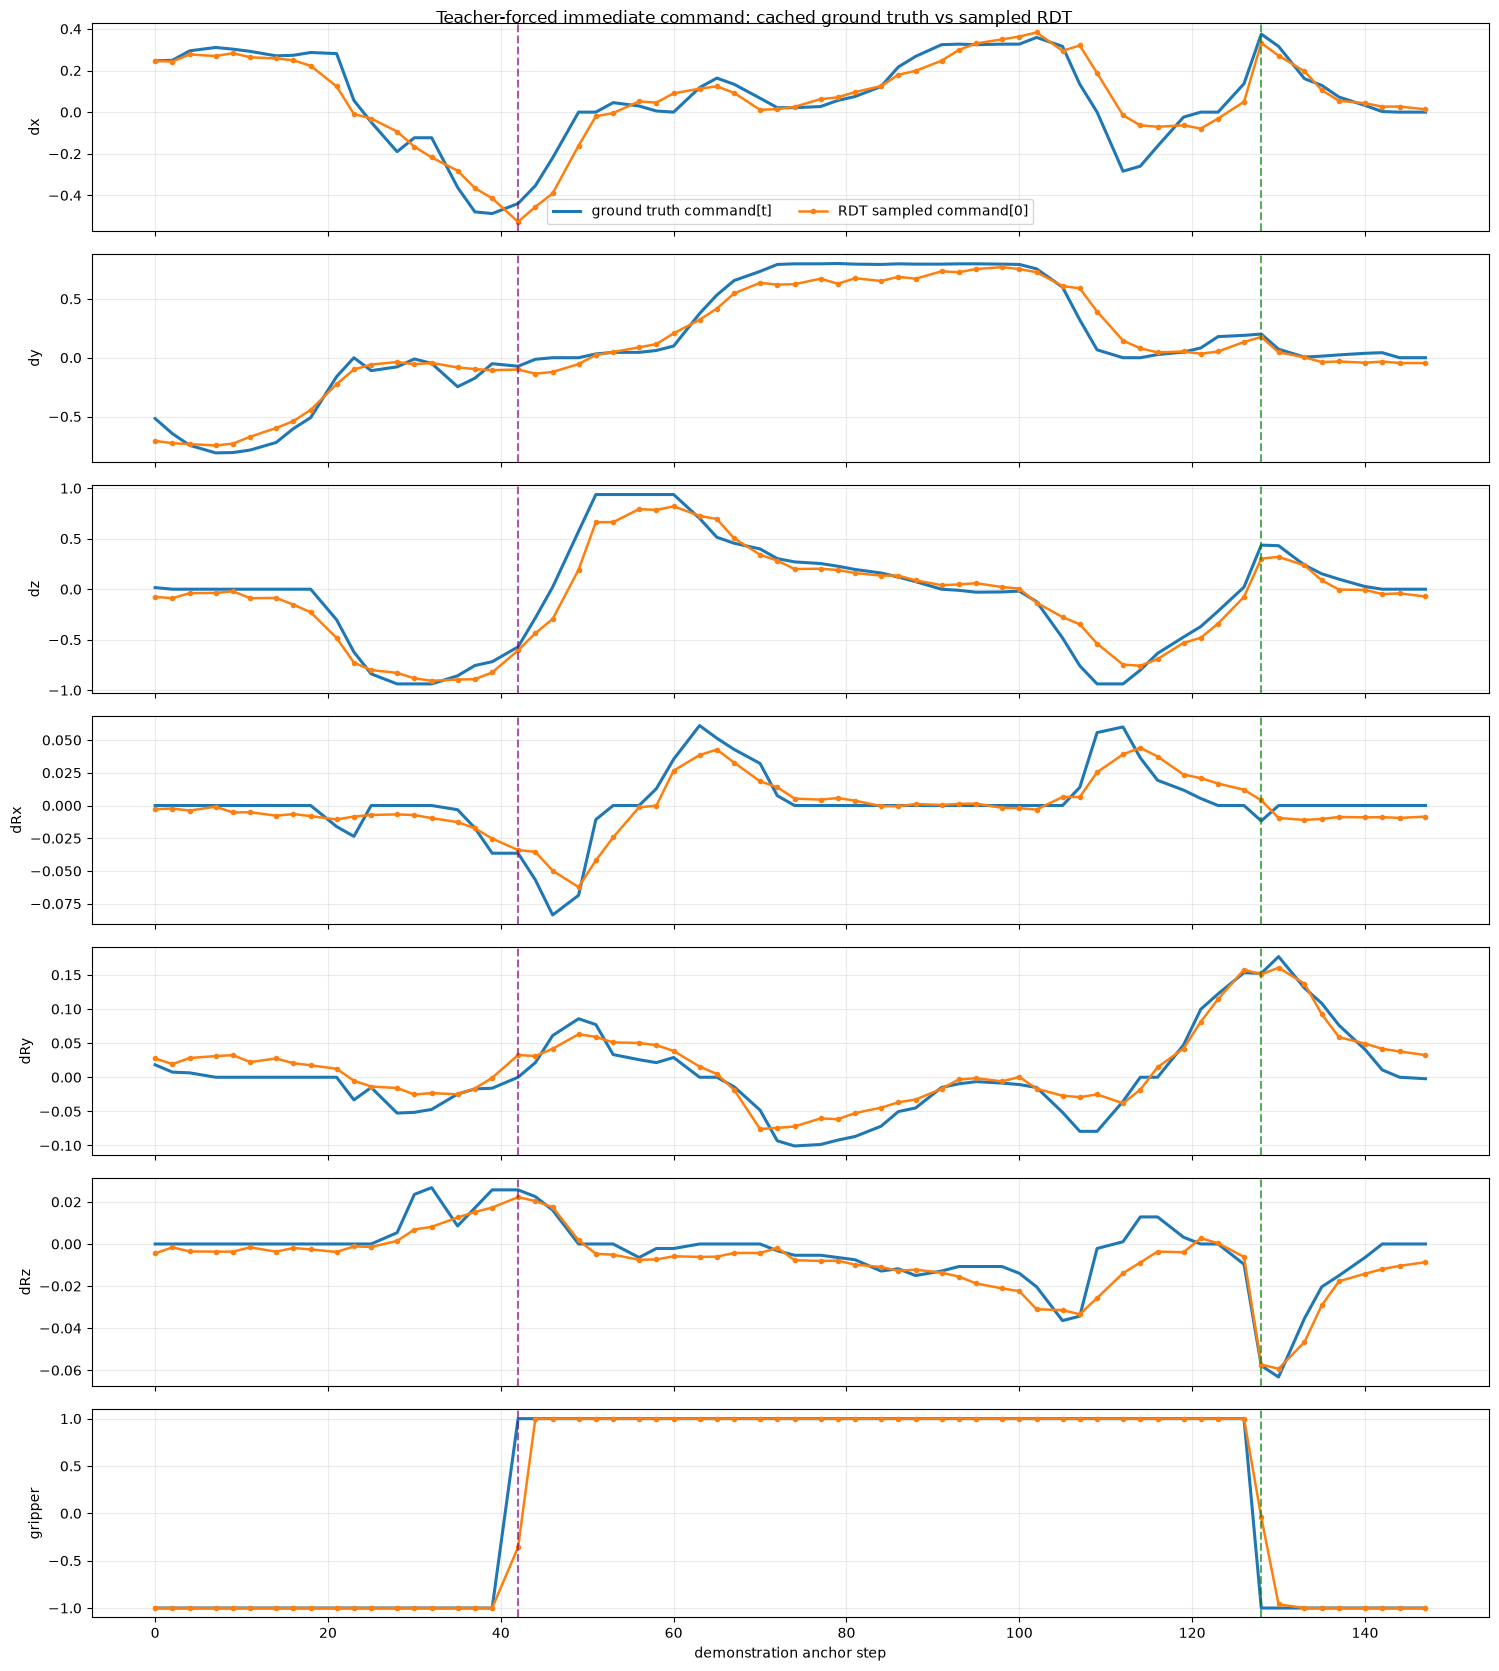

In [36]:
fig, axes = plt.subplots(7, 1, figsize=(15, 17), sharex=True)
for dim, (ax, name) in enumerate(zip(axes, command_names)):
    ax.plot(audit_steps, target_7d[:, 0, dim], color='tab:blue', linewidth=2.2, label='ground truth command[t]')
    ax.plot(audit_steps, prediction_7d[:, 0, dim], color='tab:orange', linewidth=1.8, marker='.', label='RDT sampled command[0]')
    ax.set_ylabel(name); ax.grid(alpha=.25)
    if GRASP_STEP is not None: ax.axvline(GRASP_STEP, color='purple', linestyle='--', alpha=.65)
    if RELEASE_STEP is not None: ax.axvline(RELEASE_STEP, color='green', linestyle='--', alpha=.65)
axes[0].legend(ncol=2); axes[-1].set_xlabel('demonstration anchor step')
fig.suptitle('Teacher-forced immediate command: cached ground truth vs sampled RDT')
plt.tight_layout()

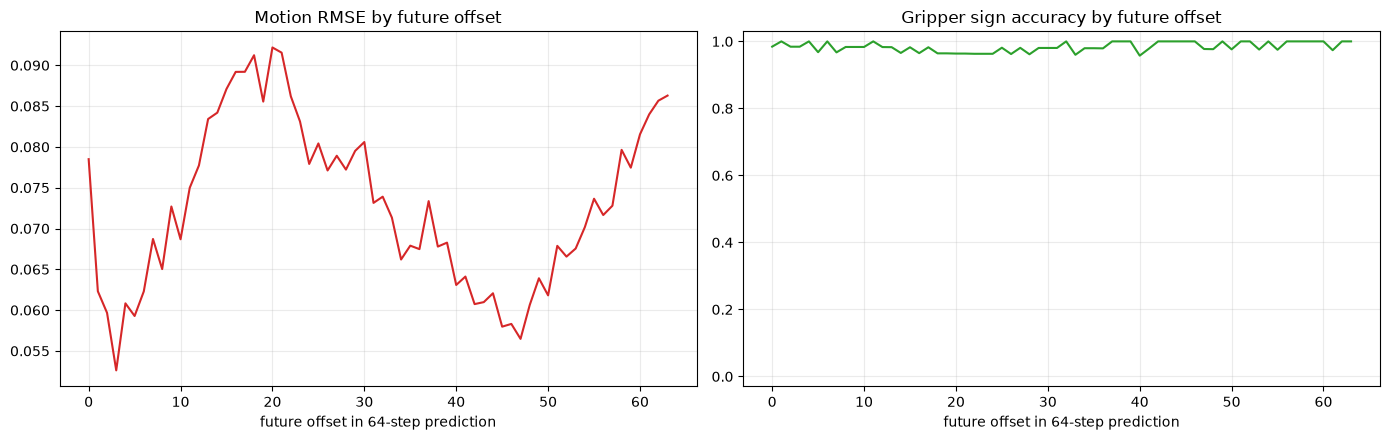

In [37]:
motion_rmse_by_offset, gripper_accuracy_by_offset = [], []
for offset in range(prediction_7d.shape[1]):
    valid = time_mask[:, offset]
    motion_rmse_by_offset.append(float(np.sqrt(np.mean((prediction_7d[valid, offset, :6] - target_7d[valid, offset, :6]) ** 2))))
    gripper_accuracy_by_offset.append(float(np.mean((prediction_7d[valid, offset, 6] >= 0) == (target_7d[valid, offset, 6] >= 0))))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(motion_rmse_by_offset, color='tab:red'); axes[0].set_title('Motion RMSE by future offset')
axes[1].plot(gripper_accuracy_by_offset, color='tab:green'); axes[1].set_ylim(-.03, 1.03); axes[1].set_title('Gripper sign accuracy by future offset')
for ax in axes: ax.set_xlabel('future offset in 64-step prediction'); ax.grid(alpha=.25)
plt.tight_layout()

## 4. Instrumented closed-loop rollout

This reproduces deployment: start from the exact `demo_0` simulator state, infer 64 actions, execute four, observe again, and repeat for at most 200 steps. It explicitly records every executed 7D command and resulting 11D physical state.

The first run loads T5, Qwen, SigLIP, RDT, and LIBERO and can take several minutes. Later runs reuse the trace unless `RERUN_LIVE_ROLLOUT=True` is set manually.

In [45]:
LIVE_DIR = RUN_ROOT / 'rollout_20260810_133253'
LIVE_VIDEO = LIVE_DIR / 'demo_0_chunk4_mask_aligned.mp4'
LIVE_TRACE = LIVE_DIR / 'demo_0_chunk4_actions.jsonl'
LIVE_OBSERVATIONS = LIVE_DIR / 'demo_0_chunk4_observations.npz'
LIVE_DIR.mkdir(parents=True, exist_ok=True)
RERUN_LIVE_ROLLOUT = not (LIVE_TRACE.exists() and LIVE_OBSERVATIONS.exists())
live_command = [
    sys.executable, str(REPO_ROOT / 'scripts/rollout_libero_rdt.py'),
    '--config', str(REPO_ROOT / 'configs/b0_rdt1b_lora.yaml'),
    '--benchmark', 'libero_object', '--task-id', '0',
    '--checkpoint', str(ARTIFACT), '--base-artifact', str(BASE_ARTIFACT),
    '--cache-root', str(CACHE_ROOT),
    '--demo-hdf5', str(DEMO_HDF5), '--demo-name', DEMO_NAME,
    '--action-chunk', '4', '--max-steps', '200', '--seed', '42',
    '--qwen-refresh-every', '1', '--clean-x0-gripper',
    '--output', str(LIVE_VIDEO),
    '--action-debug-jsonl', str(LIVE_TRACE),
    '--observation-debug-npz', str(LIVE_OBSERVATIONS),
]
print(' '.join(live_command))
if RERUN_LIVE_ROLLOUT:
    subprocess.run(live_command, cwd=REPO_ROOT, check=True)
else:
    print('Reusing existing instrumented rollout. Set RERUN_LIVE_ROLLOUT=True to replace it.')
print('Video:', LIVE_VIDEO)
print('Action trace:', LIVE_TRACE)
print('Observation trace:', LIVE_OBSERVATIONS)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python /home/ubuntu/ThinkFlow-RDT-1B/scripts/rollout_libero_rdt.py --config /home/ubuntu/ThinkFlow-RDT-1B/configs/b0_rdt1b_lora.yaml --benchmark libero_object --task-id 0 --checkpoint /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/artifact --base-artifact /home/ubuntu/ThinkFlow-RDT-1B/oxe_b0_merged_for_libero --cache-root /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_object_task0_demo0 --demo-hdf5 /home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_object/pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5 --demo-name demo_0 --action-chunk 4 --max-steps 200 --seed 42 --qwen-refresh-every 1 --clean-x0-gripper --output /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/rollout_20260810_133253/demo_0_chunk4_mask_aligned.mp4 --action-debug-jsonl /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional informa

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loading T5, SigLIP, and optional Qwen encoders...


Loading weights: 100%|██████████| 220/220 [00:06<00:00, 35.72it/s]
[transformers] T5EncoderModel LOAD REPORT from: google/t5-v1_1-xxl
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The tokenizer you are loading from 'model/model/stage1_unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/jit/_script.py:362: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.war

Loading RDT artifact /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/artifact...
Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Gripper decoding: final clean x0
[Warning]: datasets path /home/ubuntu/ThinkFlow-RDT-1B/dataset/LIBERO/Object/datasets does not exist!
plan=1 simulator_step=4 success=False elapsed=5.0s
plan=2 simulator_step=8 success=False elapsed=7.5s
plan=3 simulator_step=12 success=False elapsed=9.8s
plan=4 simulator_step=16 success=False elapsed=12.0s
plan=5 simulator_step=20 success=False elapsed=14.4s
plan=6 simulator_step=24 success=False elapsed=16.8s
plan=7 simulator_step=28 success=False elapsed=19.0s
plan=8 simulator_step=32 success=False elapsed=21.3s
plan=9 simulator_step=36 success=False elapsed=23.6s
plan=10 simulator_step=40 success=False elapsed=25.9s
plan=11 simulator_step=44 success=False elapsed=28.1s
plan=12 simulator_step=48 success=False elapsed=30.5s
plan=13 simulator_step=52 success=Fals

## 5. Load the rollout trace and locate grasp divergence

In [46]:
live_rows = [json.loads(line) for line in LIVE_TRACE.read_text().splitlines() if line.strip()]
rollout_commands_all = np.concatenate([np.asarray(row['executed_libero_actions'], dtype=np.float32) for row in live_rows])
rollout_states_all = np.concatenate([np.asarray(row['observed_rdt_states'], dtype=np.float32)[1:] for row in live_rows])
with np.load(LIVE_OBSERVATIONS) as trace:
    rollout_agent_frames = trace['agent_frames'].copy()
    rollout_wrist_frames = trace['wrist_frames'].copy()
compare_length = min(len(rollout_commands_all), len(rollout_states_all), len(demo_actions), len(demo_states) - 1)
rollout_commands = rollout_commands_all[:compare_length]
rollout_states = rollout_states_all[:compare_length]
ground_truth_commands = demo_actions[:compare_length]
ground_truth_next_states = demo_states[1:compare_length + 1]
steps = np.arange(compare_length)

def sign_transitions(values):
    signs = np.asarray(values) >= 0
    return (np.flatnonzero(signs[1:] != signs[:-1]) + 1).tolist()

display({
    'replans': len(live_rows), 'rollout_steps_recorded': len(rollout_commands_all),
    'overlap_with_demo_next_states': compare_length,
    'ground_truth_gripper_transitions': sign_transitions(ground_truth_commands[:, 6]),
    'rollout_gripper_transitions': sign_transitions(rollout_commands[:, 6]),
    'closed_loop_motion_RMSE': float(np.sqrt(np.mean((rollout_commands[:, :6] - ground_truth_commands[:, :6]) ** 2))),
    'closed_loop_gripper_accuracy': float(np.mean((rollout_commands[:, 6] >= 0) == (ground_truth_commands[:, 6] >= 0))),
})

{'replans': 50,
 'rollout_steps_recorded': 200,
 'overlap_with_demo_next_states': 147,
 'ground_truth_gripper_transitions': [42, 128],
 'rollout_gripper_transitions': [40, 44, 45],
 'closed_loop_motion_RMSE': 0.23516637086868286,
 'closed_loop_gripper_accuracy': 0.8503401360544217}

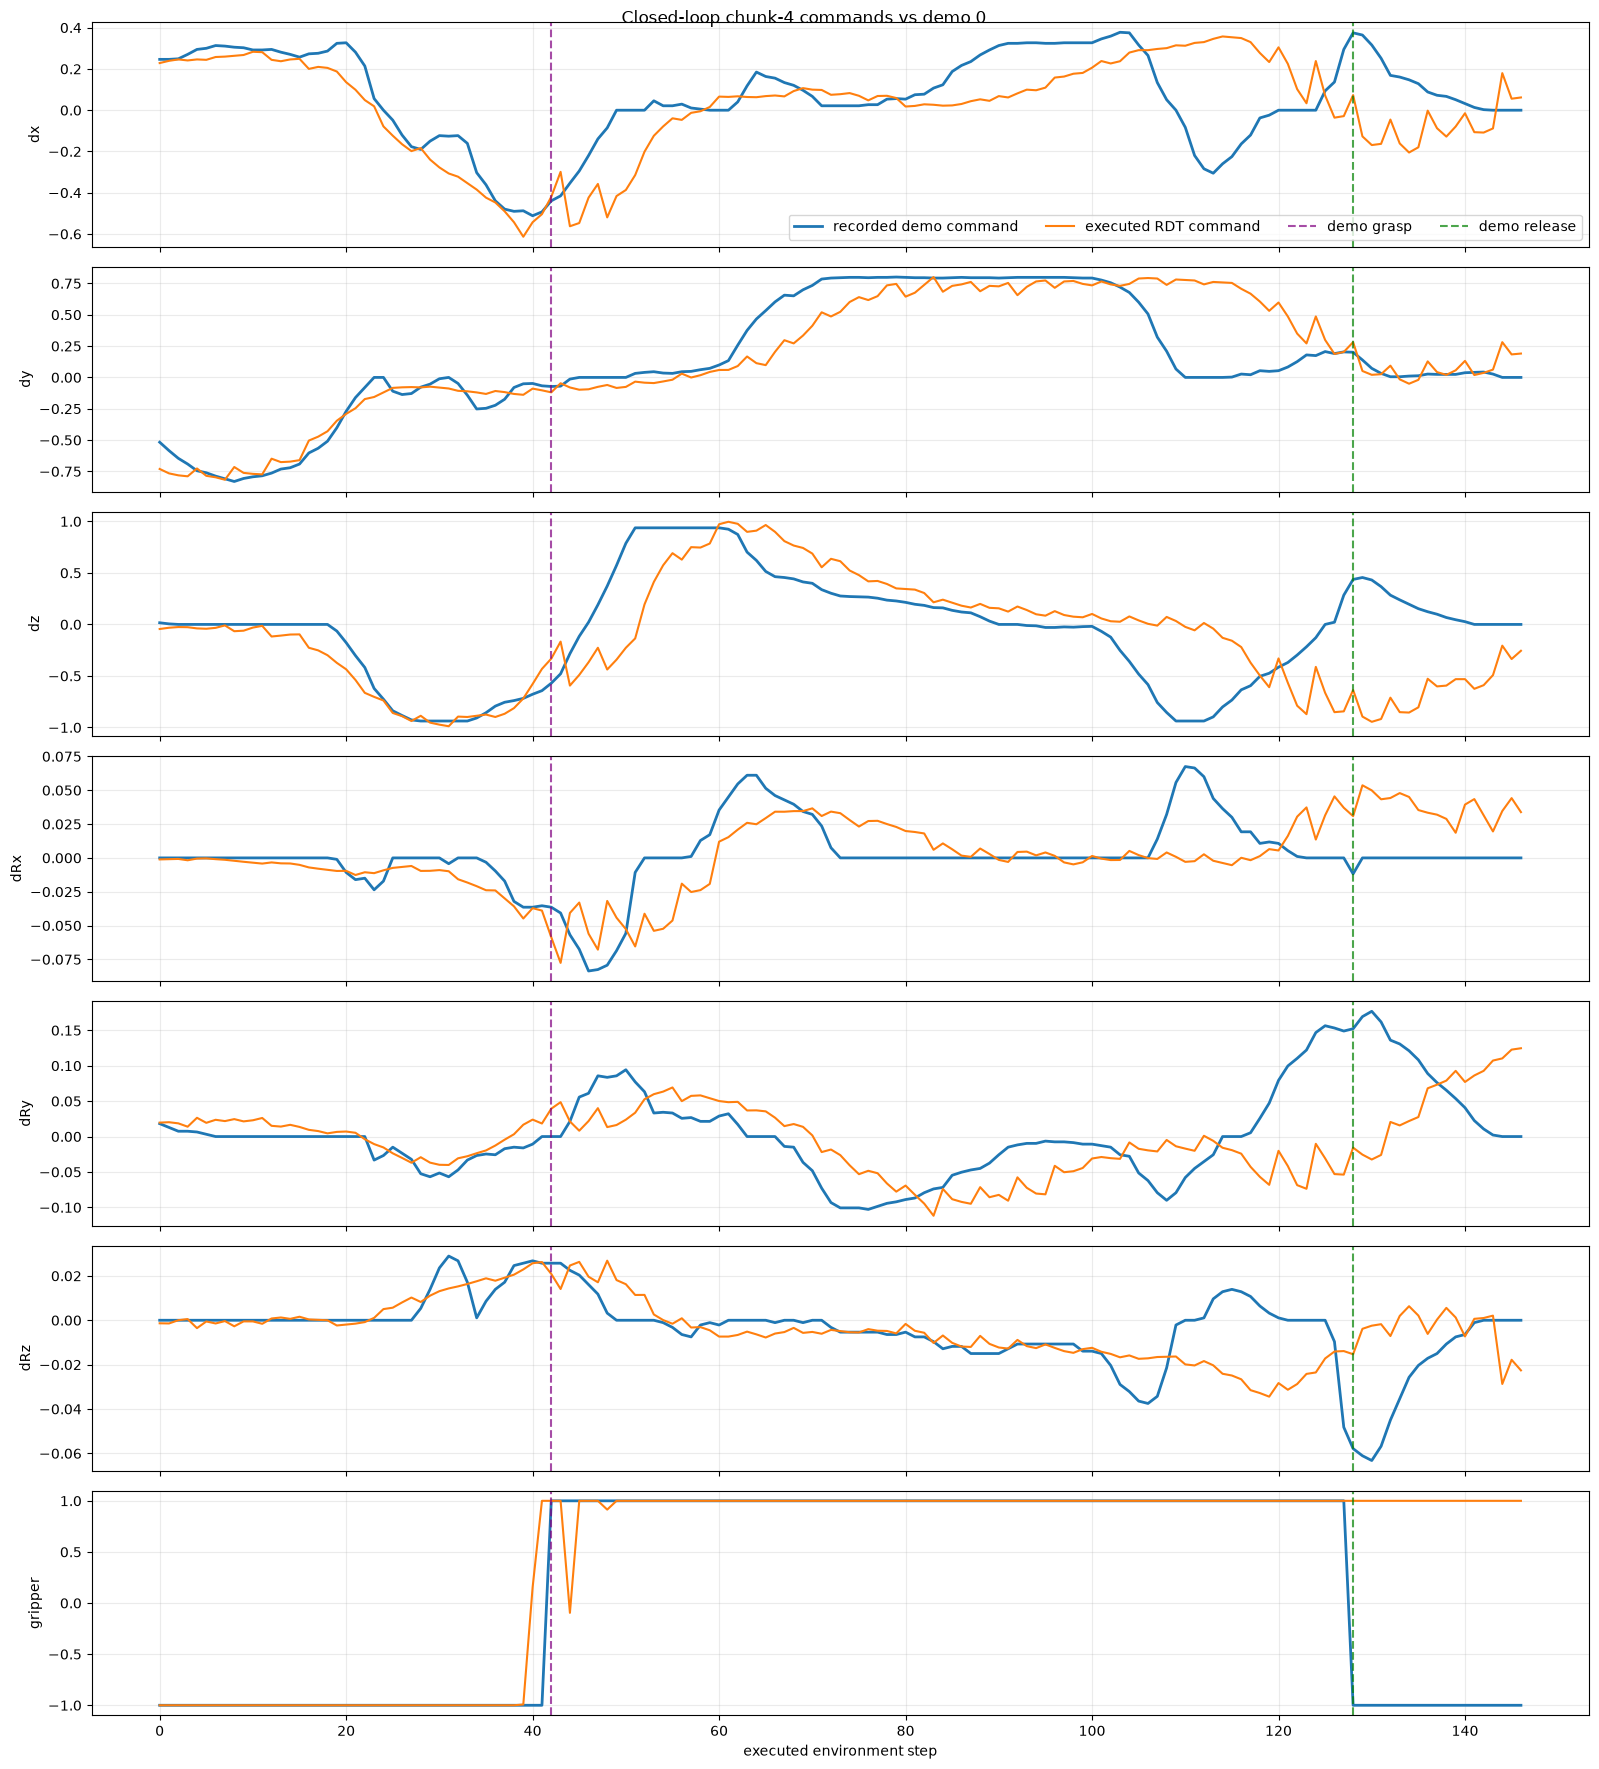

In [47]:
fig, axes = plt.subplots(7, 1, figsize=(16, 18), sharex=True)
for dim, (ax, name) in enumerate(zip(axes, command_names)):
    ax.plot(steps, ground_truth_commands[:, dim], color='tab:blue', linewidth=2.0, label='recorded demo command')
    ax.plot(steps, rollout_commands[:, dim], color='tab:orange', linewidth=1.5, label='executed RDT command')
    ax.set_ylabel(name); ax.grid(alpha=.25)
    if GRASP_STEP is not None: ax.axvline(GRASP_STEP, color='purple', linestyle='--', alpha=.7, label='demo grasp' if dim == 0 else None)
    if RELEASE_STEP is not None: ax.axvline(RELEASE_STEP, color='green', linestyle='--', alpha=.7, label='demo release' if dim == 0 else None)
axes[0].legend(ncol=4); axes[-1].set_xlabel('executed environment step')
fig.suptitle('Closed-loop chunk-4 commands vs demo 0')
plt.tight_layout()

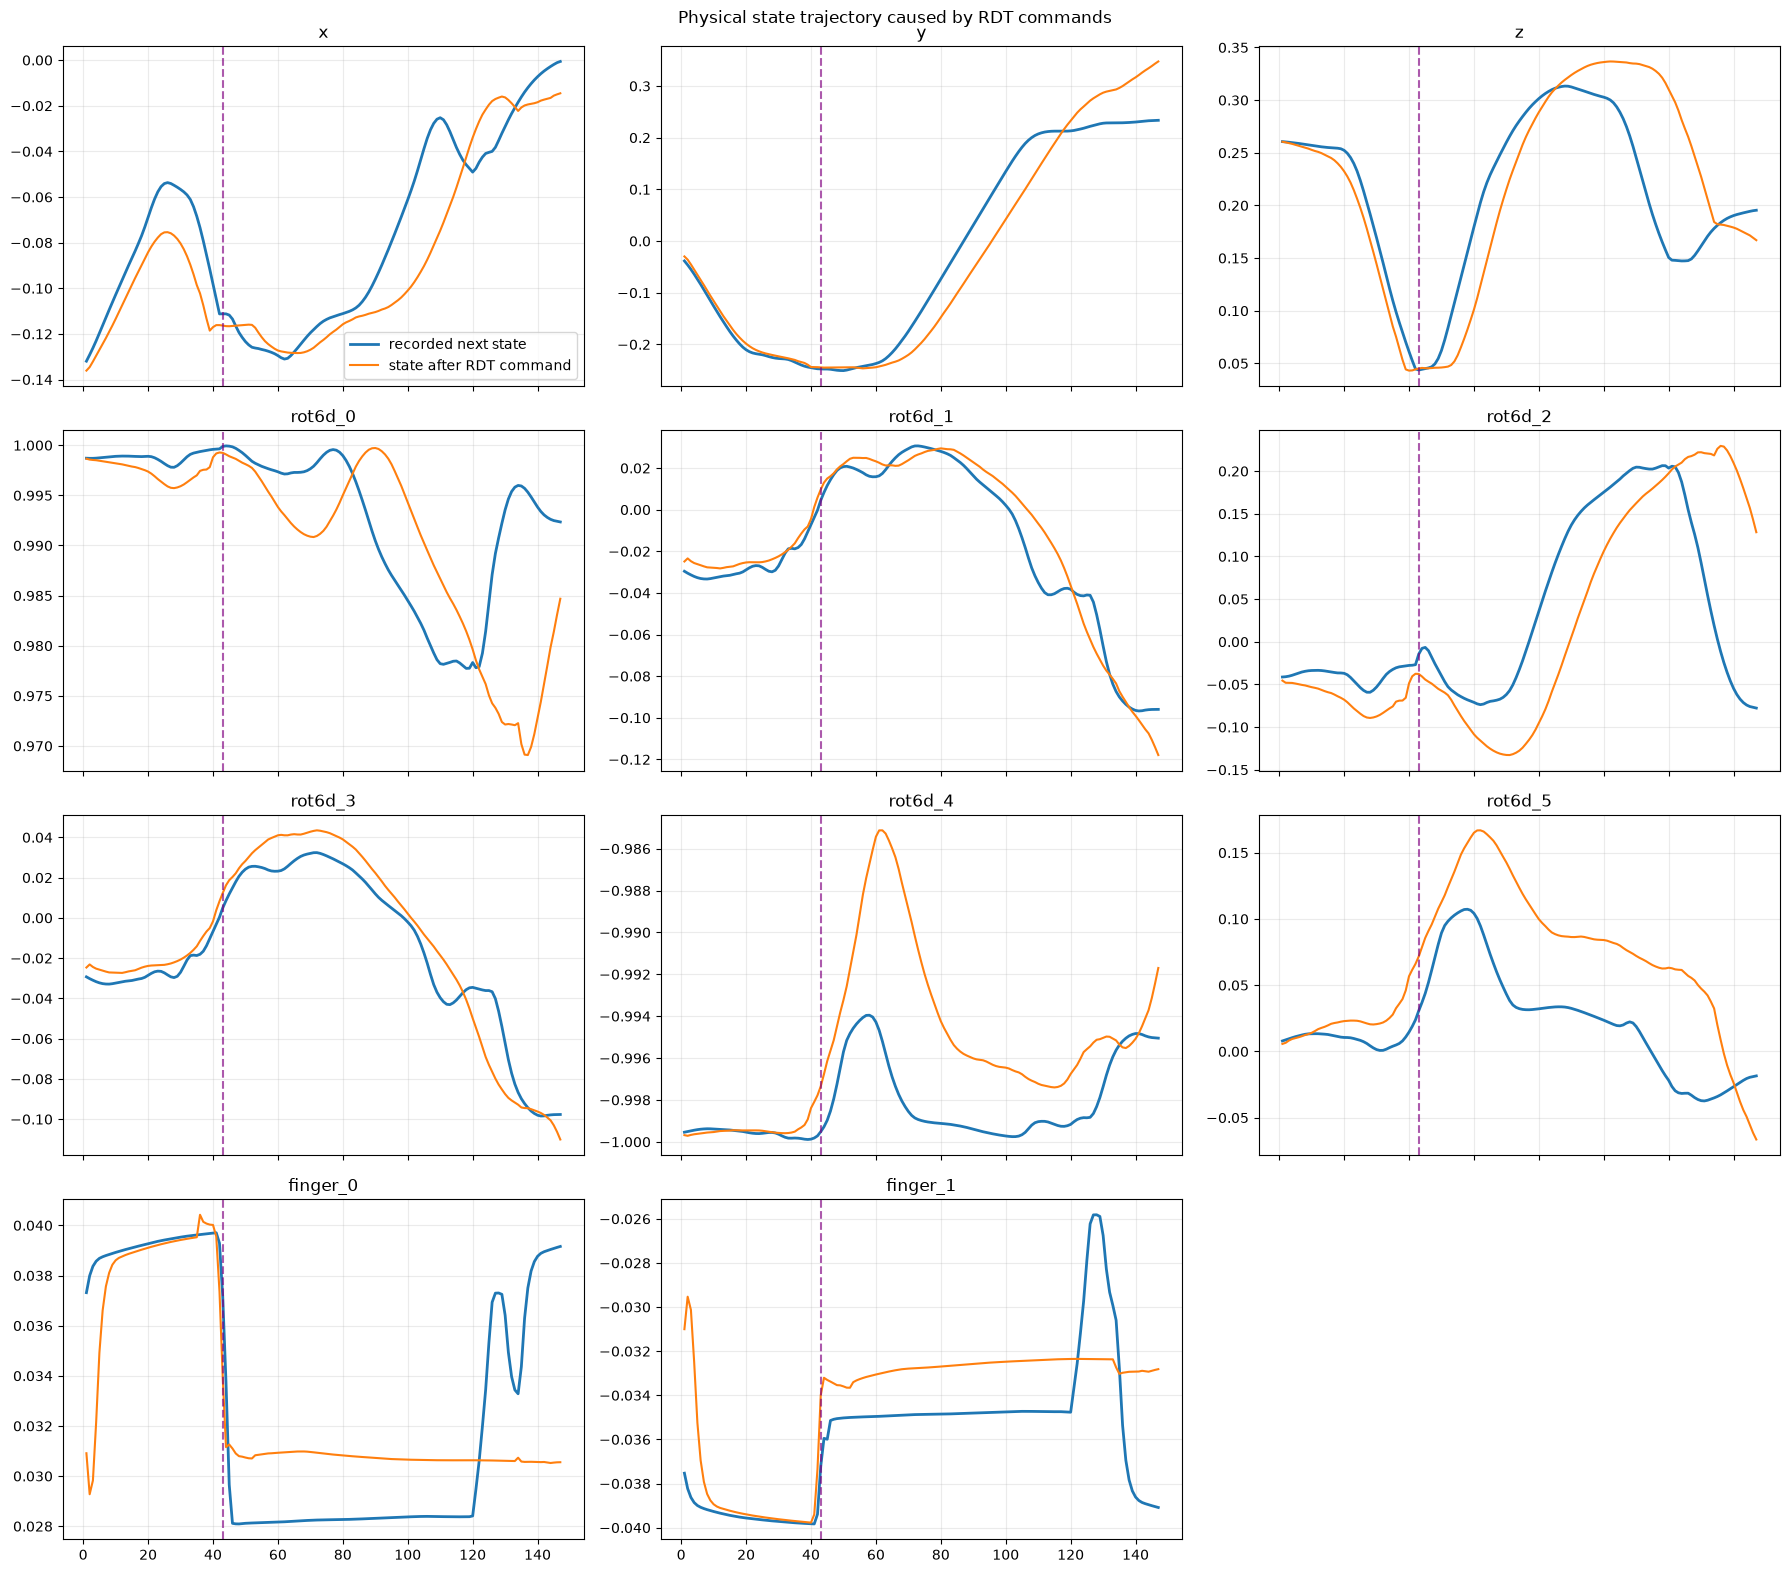

In [48]:
state_names = ['x', 'y', 'z', 'rot6d_0', 'rot6d_1', 'rot6d_2', 'rot6d_3', 'rot6d_4', 'rot6d_5', 'finger_0', 'finger_1']
fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=True)
for dim, ax in enumerate(axes.flat):
    if dim >= len(state_names): ax.axis('off'); continue
    ax.plot(steps + 1, ground_truth_next_states[:, dim], color='tab:blue', linewidth=2.0, label='recorded next state')
    ax.plot(steps + 1, rollout_states[:, dim], color='tab:orange', linewidth=1.5, label='state after RDT command')
    ax.set_title(state_names[dim]); ax.grid(alpha=.25)
    if GRASP_STEP is not None: ax.axvline(GRASP_STEP + 1, color='purple', linestyle='--', alpha=.65)
axes[0, 0].legend(); fig.suptitle('Physical state trajectory caused by RDT commands')
plt.tight_layout()

,steps,motion_command_RMSE,position_state_RMSE_m,rotation_state_RMSE_rad,finger_state_RMSE,gripper_sign_accuracy
phase,,,,,,
approach,42,0.072236,0.026976,0.034290,0.003502,0.952381
grasp_window,24,0.216666,0.038307,0.046140,0.002771,0.875000
transport,70,0.244897,0.104776,0.112132,0.003769,1.000000


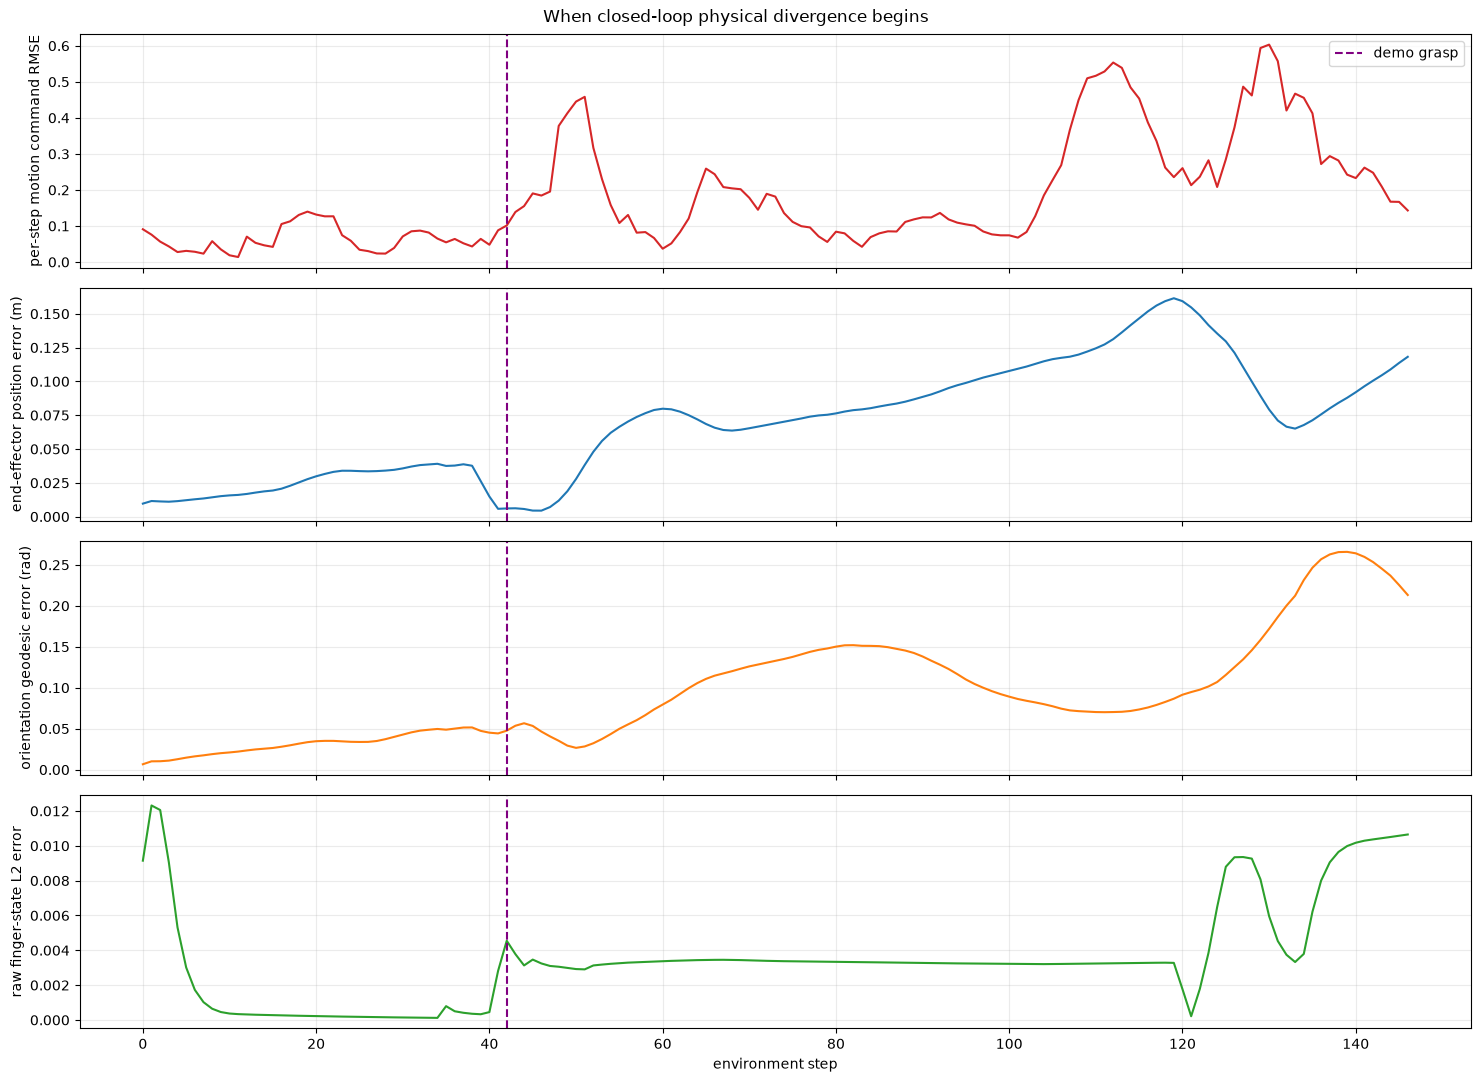

In [49]:
pred_rotation = ortho6d_to_rotation_matrix(rollout_states[:, 3:9])
true_rotation = ortho6d_to_rotation_matrix(ground_truth_next_states[:, 3:9])
relative = np.swapaxes(pred_rotation, -1, -2) @ true_rotation
rotation_error = np.arccos(np.clip((np.trace(relative, axis1=-2, axis2=-1) - 1) * .5, -1, 1))
position_error = np.linalg.norm(rollout_states[:, :3] - ground_truth_next_states[:, :3], axis=-1)
finger_error = np.linalg.norm(rollout_states[:, 9:11] - ground_truth_next_states[:, 9:11], axis=-1)
command_motion_error = np.sqrt(np.mean((rollout_commands[:, :6] - ground_truth_commands[:, :6]) ** 2, axis=-1))

phase_ranges = {
    'approach': (0, GRASP_STEP),
    'grasp_window': (max(0, GRASP_STEP - 8), min(compare_length, GRASP_STEP + 16)),
    'transport': (min(compare_length, GRASP_STEP + 16), min(compare_length, RELEASE_STEP)),
}
phase_rows = []
for phase, (start, stop) in phase_ranges.items():
    if stop is None or stop <= start: continue
    sl = slice(start, stop)
    phase_rows.append({
        'phase': phase, 'steps': stop - start,
        'motion_command_RMSE': float(np.sqrt(np.mean((rollout_commands[sl, :6] - ground_truth_commands[sl, :6]) ** 2))),
        'position_state_RMSE_m': float(np.sqrt(np.mean(position_error[sl] ** 2))),
        'rotation_state_RMSE_rad': float(np.sqrt(np.mean(rotation_error[sl] ** 2))),
        'finger_state_RMSE': float(np.sqrt(np.mean(finger_error[sl] ** 2))),
        'gripper_sign_accuracy': float(np.mean((rollout_commands[sl, 6] >= 0) == (ground_truth_commands[sl, 6] >= 0))),
    })
display(pd.DataFrame(phase_rows).set_index('phase'))

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
for ax, values, name, color in (
    (axes[0], command_motion_error, 'per-step motion command RMSE', 'tab:red'),
    (axes[1], position_error, 'end-effector position error (m)', 'tab:blue'),
    (axes[2], rotation_error, 'orientation geodesic error (rad)', 'tab:orange'),
    (axes[3], finger_error, 'raw finger-state L2 error', 'tab:green'),
):
    ax.plot(steps, values, color=color); ax.set_ylabel(name); ax.grid(alpha=.25)
    if GRASP_STEP is not None: ax.axvline(GRASP_STEP, color='purple', linestyle='--', label='demo grasp')
axes[0].legend(); axes[-1].set_xlabel('environment step')
fig.suptitle('When closed-loop physical divergence begins')
plt.tight_layout()

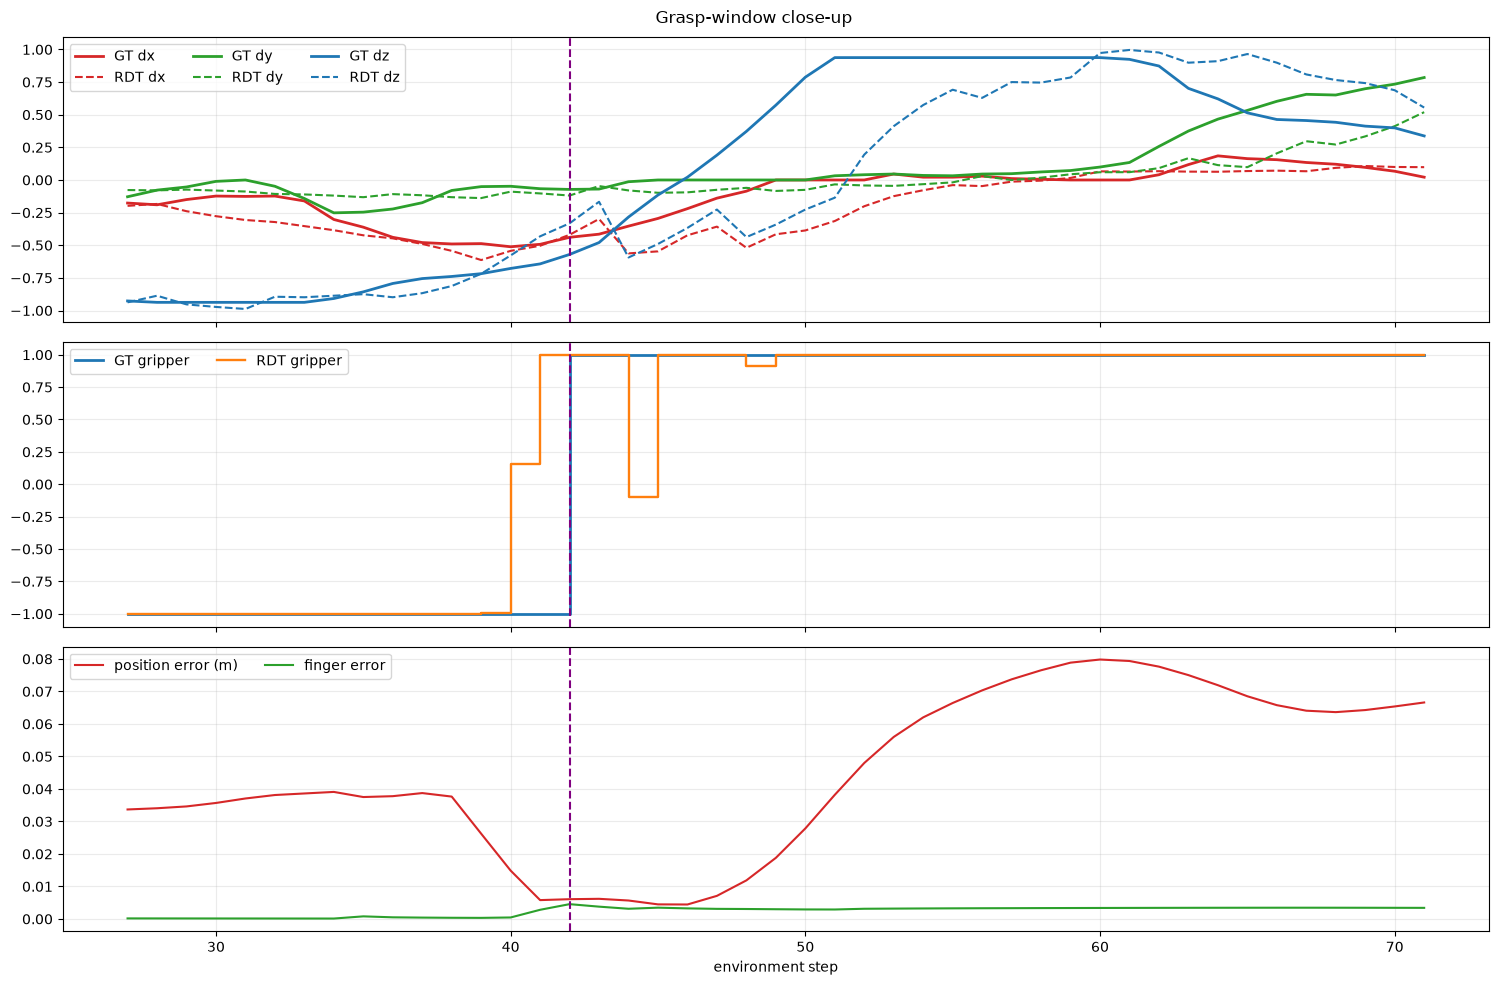

In [50]:
zoom_start = max(0, GRASP_STEP - 15)
zoom_stop = min(compare_length, GRASP_STEP + 30)
zoom = np.arange(zoom_start, zoom_stop)
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for dim, color in enumerate(('tab:red', 'tab:green', 'tab:blue')):
    axes[0].plot(zoom, ground_truth_commands[zoom, dim], color=color, linewidth=2, label=f'GT {command_names[dim]}')
    axes[0].plot(zoom, rollout_commands[zoom, dim], color=color, linestyle='--', linewidth=1.5, label=f'RDT {command_names[dim]}')
axes[1].step(zoom, ground_truth_commands[zoom, 6], where='post', color='tab:blue', linewidth=2, label='GT gripper')
axes[1].step(zoom, rollout_commands[zoom, 6], where='post', color='tab:orange', linewidth=1.7, label='RDT gripper')
axes[2].plot(zoom, position_error[zoom], color='tab:red', label='position error (m)')
axes[2].plot(zoom, finger_error[zoom], color='tab:green', label='finger error')
for ax in axes:
    ax.axvline(GRASP_STEP, color='purple', linestyle='--'); ax.grid(alpha=.25); ax.legend(ncol=3)
axes[-1].set_xlabel('environment step'); fig.suptitle('Grasp-window close-up')
plt.tight_layout()

## 6. Agent and eye-in-hand observations

Frames are the exact 128×128 policy observations recorded after execution, not separately rendered approximations.

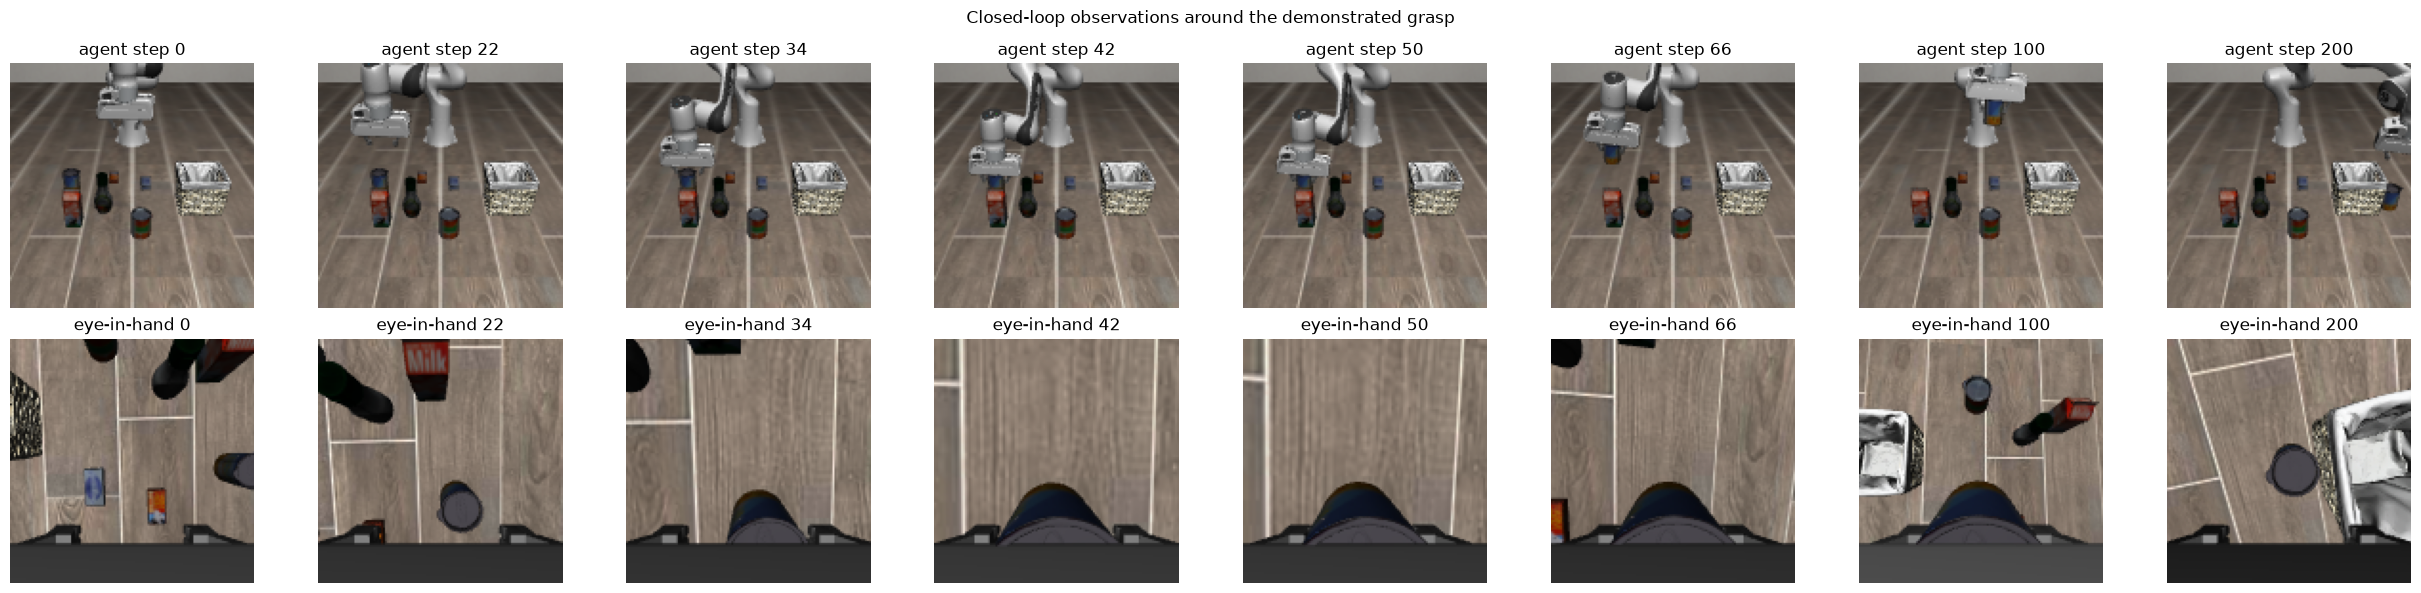

In [51]:
candidate_steps = [0, max(0, GRASP_STEP - 20), max(0, GRASP_STEP - 8), GRASP_STEP, GRASP_STEP + 8, GRASP_STEP + 24, min(len(rollout_agent_frames) - 1, 100), len(rollout_agent_frames) - 1]
camera_steps = np.asarray(sorted(set(int(np.clip(step, 0, len(rollout_agent_frames) - 1)) for step in candidate_steps)))
fig, axes = plt.subplots(2, len(camera_steps), figsize=(3.1 * len(camera_steps), 6), squeeze=False)
for column, frame_step in enumerate(camera_steps):
    axes[0, column].imshow(rollout_agent_frames[frame_step]); axes[0, column].set_title(f'agent step {frame_step}'); axes[0, column].axis('off')
    if frame_step < len(rollout_wrist_frames):
        axes[1, column].imshow(rollout_wrist_frames[frame_step]); axes[1, column].set_title(f'eye-in-hand {frame_step}')
    else:
        axes[1, column].text(.5, .5, 'unavailable', ha='center', va='center')
    axes[1, column].axis('off')
fig.suptitle('Closed-loop observations around the demonstrated grasp')
plt.tight_layout()
display(Video(str(LIVE_VIDEO), embed=True, width=720))

## 7. Automated interpretation checklist

This is deliberately conservative. The plots above remain the source of truth.

In [30]:
h4_motion_rmse = rows[1]['motion_RMSE']
gt_close = sign_transitions(ground_truth_commands[:, 6])
rdt_close = sign_transitions(rollout_commands[:, 6])
print('Final weighted / unweighted denoising loss:', final_training['weighted_imitation_loss'], '/', final_training['unweighted_denoising_loss'])
print('Teacher-forced H4 motion RMSE:', h4_motion_rmse)
print('GT / RDT gripper transitions:', gt_close, '/', rdt_close)
print('Position error at demonstrated grasp:', float(position_error[min(GRASP_STEP, len(position_error)-1)]), 'm')
print('Finger-state error at demonstrated grasp:', float(finger_error[min(GRASP_STEP, len(finger_error)-1)]))
if final_training['unweighted_denoising_loss'] > 0.01:
    print('Finding: after removing the mask shortcut, 200 optimizer steps did not yet reach the previous low-loss regime.')
if h4_motion_rmse > 0.15:
    print('Finding: motion is already inaccurate on demonstrated observations; this is not only closed-loop compounding.')
else:
    print('Finding: cached short-horizon motion is reasonably close; inspect where closed-loop state error begins growing.')
if float(position_error[min(GRASP_STEP, len(position_error)-1)]) > 0.02:
    print('Finding: the end effector is over 2 cm from the demonstrated pose at grasp time, enough to explain a missed grasp.')
if gt_close != rdt_close:
    print('Finding: the closed-loop gripper transition schedule also differs from the demonstration.')
print('Do not infer grasp success from gripper accuracy alone: a correctly timed close still fails if xyz/orientation has drifted.')

Final weighted / unweighted denoising loss: 0.00800323486328125 / 0.00762176513671875
Teacher-forced H4 motion RMSE: 0.08054133504629135
GT / RDT gripper transitions: [42, 128] / []
Position error at demonstrated grasp: 0.040146604180336 m
Finger-state error at demonstrated grasp: 0.003596533089876175
Finding: cached short-horizon motion is reasonably close; inspect where closed-loop state error begins growing.
Finding: the end effector is over 2 cm from the demonstrated pose at grasp time, enough to explain a missed grasp.
Finding: the closed-loop gripper transition schedule also differs from the demonstration.
Do not infer grasp success from gripper accuracy alone: a correctly timed close still fails if xyz/orientation has drifted.
